# Composer Classification of MIDI Music with LSTM and CNN Models

**Deep Learning Final Project**

This notebook develops and compares two deep learning models - a **Long Short-Term Memory (LSTM)** network and a **Convolutional Neural Network (CNN)** - that predict the composer of a MIDI musical composition. The composer classes are read directly from the dataset folders (nine composers: bach, bartok, byrd, chopin, handel, hummel, mendelssohn, mozart, schumann).

## Project overview

Each architecture receives a representation that suits it. The LSTM consumes *ordered note-pitch sequences* (an event stream), which matches its strength at modeling temporal order. The CNN consumes *piano-roll matrices* (a 2-D pitch-by-time image), which matches its strength at detecting local 2-D patterns such as chords and textures. Both models are trained, tuned, and evaluated on the same train/validation/test partition, and their results are compared directly.

## How to run this notebook

**Local Jupyter:**
1. Make sure the Composer Dataset is available at `../build/datasets/Composer_Dataset/NN_midi_files_extended` (relative to this notebook). It must contain `train/`, `dev/`, and `test/` folders, each with one sub-folder per composer.
2. Run the *Setup* cells to install libraries.
3. Run the notebook top to bottom.

Everything is CPU-compatible; a GPU only speeds up training.

> **Reproducibility & honesty note.** All metrics, tables, and figures in this notebook are produced by the code at run time. Nothing is hard-coded. Cells that print final numbers are marked so you can copy the printed values into the report. If a step cannot run (for example, the dataset is missing), the code fails loudly with a clear message rather than silently continuing.


## 1. Setup: install and import libraries

The next cell installs the third-party libraries the notebook needs (`pretty_midi` and `music21` are usually not pre-installed). The install cell is safe to re-run.

In [3]:
# Must run before any TensorFlow import so env vars and CUDA libs are in place
import os, sys

# Prepend notebook directory so utilsTF.py is importable
sys.path.insert(0, os.path.dirname(os.path.abspath("FirstPass.ipynb")))

from utilsTF import load_cuda_libraries, configure_tensorflow

load_cuda_libraries()      # pre-load nvidia .so files into process memory
configure_tensorflow()     # set XLA_FLAGS and TF_CPP_MIN_LOG_LEVEL before TF loads

✓ Loaded CUDA libraries from /home/maxim/miniconda3/envs/511-team-project-2/lib/python3.11/site-packages/nvidia


In [4]:
from utilsTF import test_gpu

test_gpu()   # enable memory growth and report available GPUs

✓ GPU setup complete - 1 GPU(s) available


1

In [5]:
# --- Imports ---
import os, re, glob, hashlib, random, warnings, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MIDI parsing (with graceful failure if unavailable)
try:
    import pretty_midi
except ImportError as e:
    raise ImportError(
        "pretty_midi is required. Run the install cell above, then restart the "
        "runtime and re-run."
    ) from e

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pretty_midi.pretty_midi.MAX_TICK = 1e7  # tolerate long files without warnings
sns.set_context("notebook")
print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.16.1
GPU available: True


## 2. Configuration and random seeds

All tunable constants live here so the notebook has a single control panel. `DATASET_PATH` is the **only** path you normally need to change. Random seeds are fixed for NumPy, Python, and TensorFlow so runs are reproducible (small non-determinism can still occur on GPU).

In [6]:
# ----------------------------- CONFIG --------------------------------------
# Same datasource as FirstPass.ipynb: pre-split Composer Dataset with
# train/dev/test folders, one sub-folder per composer.
DATASET_PATH = "../build/datasets/Composer_Dataset/NN_midi_files_extended"
SPLIT_DIRS   = {"train": "train", "val": "dev", "test": "test"}

# Composer classes are read from the dataset's train folder.
TARGET_COMPOSERS = sorted(
    d for d in os.listdir(os.path.join(DATASET_PATH, SPLIT_DIRS["train"]))
    if not d.startswith("."))

# LSTM (note-sequence) settings
SEQ_LEN      = 100        # notes per training window
SEQ_STRIDE   = 50         # hop between windows (controls overlap / augmentation)
PITCH_VOCAB  = 128        # MIDI pitches 0-127
PAD_TOKEN    = 128        # reserved padding index -> embedding input_dim = 129

# CNN (piano-roll) settings
PR_FS        = 8          # piano-roll sampling frequency (frames per second)
PR_TIME      = 128        # time frames per window
PR_PITCH     = 128        # pitch rows (fixed by MIDI)
PR_STRIDE    = 64         # hop between piano-roll windows

# Training settings (the train/val/test split is predefined by the dataset)
BATCH_SIZE   = 64
MAX_EPOCHS   = 60
PATIENCE     = 8
SEED         = 42

# Data-augmentation (training split only)
AUG_TRANSPOSITIONS = [-2, -1, 1, 2]   # semitone shifts; [] disables transposition

# Optional caps to keep runtime reasonable on limited hardware.
# Set to None to use every file / window.
MAX_FILES_PER_COMPOSER   = None
MAX_WINDOWS_PER_FILE     = 20
# ---------------------------------------------------------------------------

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

set_seeds()
LABEL2IDX = {c: i for i, c in enumerate(TARGET_COMPOSERS)}
IDX2LABEL = {i: c for c, i in LABEL2IDX.items()}
print("Label encoding:", LABEL2IDX)

Label encoding: {'bach': 0, 'bartok': 1, 'byrd': 2, 'chopin': 3, 'handel': 4, 'hummel': 5, 'mendelssohn': 6, 'mozart': 7, 'schumann': 8}


## 3. Dataset loading

**Dataset:** the *Composer Dataset* (`NN_midi_files_extended`), the same datasource used by `FirstPass.ipynb`. It ships with **predefined train/dev/test splits**: the directory contains `train/`, `dev/`, and `test/` folders, each holding one sub-folder per composer with `.mid` files inside.

No download or upload step is needed - the data lives in the repository at `../build/datasets/Composer_Dataset/NN_midi_files_extended`. The cell below verifies the directory layout and reports file counts per split.

In [7]:
# --- Verify the dataset directory layout -------------------------------------
if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"DATASET_PATH does not exist: {DATASET_PATH}\n"
        "Expected the Composer_Dataset at ../build/datasets/Composer_Dataset/"
        "NN_midi_files_extended (relative to this notebook).")

print(f"Dataset root: {os.path.abspath(DATASET_PATH)}")
print(f"Composers ({len(TARGET_COMPOSERS)}): {TARGET_COMPOSERS}\n")

for split, folder in SPLIT_DIRS.items():
    split_root = Path(DATASET_PATH) / folder
    n = sum(1 for _ in split_root.rglob("*.mid")) + sum(1 for _ in split_root.rglob("*.MID"))
    print(f"  {split:5s} ({folder}/): {n} MIDI files")

Dataset root: /mnt/d/Documents/MachineLearning/TeamProject-511/build/datasets/Composer_Dataset/NN_midi_files_extended
Composers (9): ['bach', 'bartok', 'byrd', 'chopin', 'handel', 'hummel', 'mendelssohn', 'mozart', 'schumann']

  train (train/): 369 MIDI files
  val   (dev/): 35 MIDI files
  test  (test/): 35 MIDI files


## 4. Dataset inspection, filtering, and label creation

The dataset layout is fixed: `<split>/<composer>/<file>.mid`. The code walks the three split folders (`train/`, `dev/`, `test/`), takes the **composer label from the parent folder name**, and remembers which split each file belongs to. This step also performs **de-duplication by MD5 hash** so identical files cannot leak across splits, and drops files that are unreadable or too short to yield a training window.

In [8]:
def collect_midi_files(root, split_dirs=SPLIT_DIRS, composers=TARGET_COMPOSERS):
    """Walk <root>/<split>/<composer>/ and return one record per MIDI file."""
    records = []
    for split, folder in split_dirs.items():
        for comp in composers:
            comp_dir = Path(root) / folder / comp
            if not comp_dir.is_dir():
                continue
            for ext in ("*.mid", "*.midi", "*.MID", "*.MIDI"):
                for f in comp_dir.rglob(ext):
                    records.append({"path": str(f), "composer": comp, "split": split})
    return (pd.DataFrame(records)
              .drop_duplicates(subset="path")
              .sort_values("path")
              .reset_index(drop=True))

raw_df = collect_midi_files(DATASET_PATH)
if len(raw_df) == 0:
    raise RuntimeError("No MIDI files found. Check DATASET_PATH and the dataset contents.")

print(f"Total MIDI files found: {len(raw_df)}")
print("\nFiles per split:")
print(raw_df["split"].value_counts())
print("\nRaw counts per composer (before cleaning):")
print(raw_df["composer"].value_counts())

Total MIDI files found: 439

Files per split:
split
train    369
val       35
test      35
Name: count, dtype: int64

Raw counts per composer (before cleaning):
composer
bach           50
byrd           50
hummel         50
bartok         49
chopin         49
handel         49
mendelssohn    49
mozart         49
schumann       44
Name: count, dtype: int64


In [9]:
# --- De-duplicate by content hash and drop unreadable files ------------------
def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

raw_df["md5"] = raw_df["path"].map(md5_of)
before = len(raw_df)
dedup_df = raw_df.drop_duplicates(subset="md5").reset_index(drop=True)
print(f"Duplicate files removed: {before - len(dedup_df)}")

# Validate that each file is parseable; record note counts.
def probe_midi(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(inst.notes) for inst in pm.instruments)
        return n_notes
    except Exception:
        return -1   # unreadable / invalid

dedup_df["n_notes"] = dedup_df["path"].map(probe_midi)
unreadable = int((dedup_df["n_notes"] < 0).sum())
empty      = int((dedup_df["n_notes"] == 0).sum())
print(f"Unreadable / invalid MIDI files: {unreadable}")
print(f"Readable but empty (no notes):   {empty}")

# Keep only files with a usable number of notes for at least one window.
clean_df = dedup_df[dedup_df["n_notes"] >= SEQ_LEN].reset_index(drop=True)
print(f"\nUsable files (>= {SEQ_LEN} notes): {len(clean_df)}")
print("\nUsable counts per composer (after cleaning):")
print(clean_df["composer"].value_counts())

Duplicate files removed: 3
Unreadable / invalid MIDI files: 0
Readable but empty (no notes):   0

Usable files (>= 100 notes): 436

Usable counts per composer (after cleaning):
composer
bach           50
byrd           50
hummel         50
bartok         49
chopin         49
mendelssohn    49
mozart         49
handel         48
schumann       42
Name: count, dtype: int64


### 4.1 Before/after summary and class distribution

The table below reports usable file counts per composer **before and after** preprocessing, satisfying the requirement to document data availability explicitly. The bar chart visualizes class balance; any strong imbalance is addressed later with class weights during training.

File counts per composer:

             raw_matched  after_dedup  usable
composer                                     
bach                  50           50      50
bartok                49           49      49
byrd                  50           50      50
chopin                49           49      49
handel                49           48      48
hummel                50           50      50
mendelssohn           49           49      49
mozart                49           49      49
schumann              44           42      42
TOTAL                439          436     436


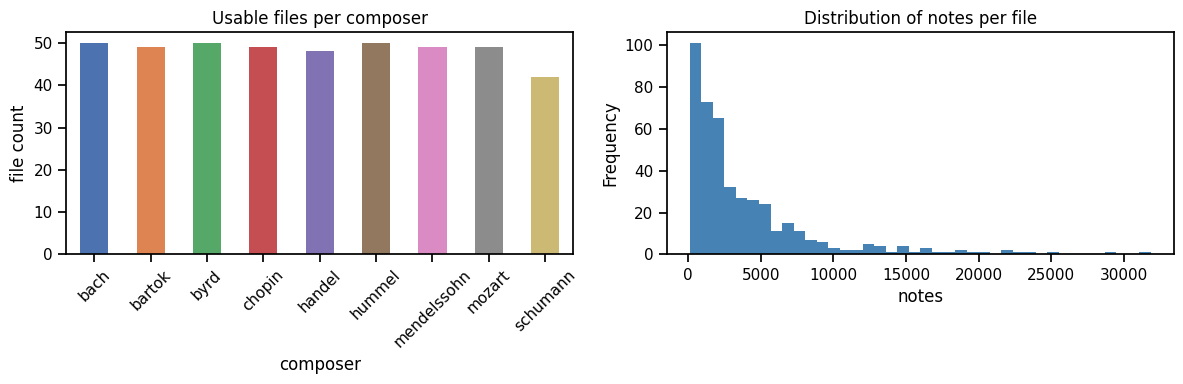

In [10]:
summary = (pd.DataFrame({
        "raw_matched": raw_df["composer"].value_counts(),
        "after_dedup": dedup_df["composer"].value_counts(),
        "usable":      clean_df["composer"].value_counts(),
    })
    .reindex(TARGET_COMPOSERS)
    .fillna(0).astype(int))
summary.loc["TOTAL"] = summary.sum()
print("File counts per composer:\n")
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
clean_df["composer"].value_counts().reindex(TARGET_COMPOSERS).plot(
    kind="bar", ax=ax[0], color=sns.color_palette("deep", len(TARGET_COMPOSERS)))
ax[0].set_title("Usable files per composer"); ax[0].set_ylabel("file count")
ax[0].tick_params(axis="x", rotation=45)
clean_df["n_notes"].plot(kind="hist", bins=40, ax=ax[1], color="steelblue")
ax[1].set_title("Distribution of notes per file"); ax[1].set_xlabel("notes")
plt.tight_layout(); plt.show()

## 5. Train / validation / test splitting (leakage-safe)

**The split is predefined by the dataset**: the `train/`, `dev/`, and `test/` folders determine which files go where (`dev` serves as the validation set). Because splitting happens at the file level, before any windowing, every window from a given composition stays inside a single split - windows from one piece can never land in both training and test sets, which would let the model memorize a piece rather than a composer. The MD5 de-duplication from Section 4 additionally guarantees that no identical file appears in two splits, and the assertion below verifies it.

In [11]:
split_df = clean_df.copy()

# Optional per-composer cap for speed (applied to the training split only).
if MAX_FILES_PER_COMPOSER is not None:
    rng = np.random.RandomState(SEED)
    capped = []
    for (split, comp), grp in split_df.groupby(["split", "composer"]):
        if split == "train" and len(grp) > MAX_FILES_PER_COMPOSER:
            grp = grp.iloc[rng.permutation(len(grp))[:MAX_FILES_PER_COMPOSER]]
        capped.append(grp)
    split_df = pd.concat(capped).sort_index().reset_index(drop=True)

# Use the dataset's predefined folders: train -> train, dev -> val, test -> test.
def split_arrays(name):
    part = split_df[split_df["split"] == name]
    return part["path"].values, part["composer"].map(LABEL2IDX).values

f_train, y_train = split_arrays("train")
f_val,   y_val   = split_arrays("val")
f_test,  y_test  = split_arrays("test")

print(f"Files -> train: {len(f_train)}  val: {len(f_val)}  test: {len(f_test)}")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = {IDX2LABEL[i]: int((y == i).sum()) for i in range(len(TARGET_COMPOSERS))}
    print(f"  {name:5s} class counts: {dist}")

# Sanity check: no file appears in more than one split.
assert set(f_train) & set(f_test) == set()
assert set(f_train) & set(f_val)  == set()
assert set(f_val)   & set(f_test) == set()
print("Leakage check passed: splits are disjoint at the file level.")

Files -> train: 366  val: 35  test: 35
  train class counts: {'bach': 42, 'bartok': 41, 'byrd': 42, 'chopin': 41, 'handel': 40, 'hummel': 42, 'mendelssohn': 41, 'mozart': 41, 'schumann': 36}
  val   class counts: {'bach': 4, 'bartok': 4, 'byrd': 4, 'chopin': 4, 'handel': 4, 'hummel': 4, 'mendelssohn': 4, 'mozart': 4, 'schumann': 3}
  test  class counts: {'bach': 4, 'bartok': 4, 'byrd': 4, 'chopin': 4, 'handel': 4, 'hummel': 4, 'mendelssohn': 4, 'mozart': 4, 'schumann': 3}
Leakage check passed: splits are disjoint at the file level.


## 6. Feature extraction

Two representations are extracted from the **same** MIDI files, one tailored to each model.

**LSTM - note-pitch sequences.** Every note across all instruments is sorted by onset time, and its MIDI pitch (0-127) becomes a token. The stream is cut into overlapping windows of `SEQ_LEN` notes (hop `SEQ_STRIDE`). Ordered pitch tokens preserve melodic and harmonic motion over time, which is what a recurrent network is built to model. An `Embedding` layer turns each pitch token into a learned dense vector.

**CNN - piano-roll windows.** `pretty_midi.get_piano_roll(fs=PR_FS)` produces a 128 x time matrix of note activity. It is binarized and cut into `PR_PITCH` x `PR_TIME` windows (hop `PR_STRIDE`). A piano roll is effectively an image of the music, so 2-D convolutions can pick up chords (vertical structure) and rhythmic/melodic motifs (horizontal structure).

Because both representations are windowed, one file yields several samples - a form of **sequence-window augmentation** that also enlarges the dataset.

In [12]:
def extract_note_sequence(path):
    """Return a 1-D array of pitch tokens ordered by onset time, or None."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
    except Exception:
        return None
    notes = [(n.start, n.pitch) for inst in pm.instruments
             if not inst.is_drum for n in inst.notes]
    if len(notes) < SEQ_LEN:
        return None
    notes.sort(key=lambda x: x[0])
    return np.array([p for _, p in notes], dtype=np.int16)

def sequence_windows(seq, seq_len=SEQ_LEN, stride=SEQ_STRIDE, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, len(seq) - seq_len + 1, stride):
        out.append(seq[start:start + seq_len])
        if cap is not None and len(out) >= cap:
            break
    return out

def extract_piano_roll(path):
    """Return a binarized 128 x time piano roll, or None."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
    except Exception:
        return None
    if len(pm.instruments) == 0:
        return None
    roll = pm.get_piano_roll(fs=PR_FS)            # (128, T) velocity
    if roll.shape[1] < PR_TIME:
        return None
    return (roll > 0).astype(np.float32)          # binarize

def roll_windows(roll, t=PR_TIME, stride=PR_STRIDE, cap=MAX_WINDOWS_PER_FILE):
    out = []
    for start in range(0, roll.shape[1] - t + 1, stride):
        out.append(roll[:, start:start + t])
        if cap is not None and len(out) >= cap:
            break
    return out

print("Feature-extraction helpers defined.")

Feature-extraction helpers defined.


### 6.1 Build windowed datasets per split

The helper below turns a list of files into arrays of windows plus matching labels. **Augmentation (pitch transposition) is applied to the training split only**; validation and test windows are never augmented, preserving an honest estimate of generalization. Transposition by a few semitones changes key but preserves intervals and contour, so the composer's style is retained.

In [13]:
def transpose_sequence(seq, shift):
    out = seq.astype(np.int16) + shift
    out = np.clip(out, 0, PITCH_VOCAB - 1)
    return out

def transpose_roll(roll, shift):
    out = np.zeros_like(roll)
    if shift == 0:
        return roll
    if shift > 0:
        out[shift:, :] = roll[:-shift, :]
    else:
        out[:shift, :] = roll[-shift:, :]
    return out

def build_sequence_split(files, labels, augment=False):
    X, y = [], []
    skipped = 0
    for path, lab in zip(files, labels):
        seq = extract_note_sequence(path)
        if seq is None:
            skipped += 1
            continue
        for w in sequence_windows(seq):
            X.append(w); y.append(lab)
            if augment:
                for s in AUG_TRANSPOSITIONS:
                    X.append(transpose_sequence(w, s)); y.append(lab)
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32), skipped

def build_roll_split(files, labels, augment=False):
    X, y = [], []
    skipped = 0
    for path, lab in zip(files, labels):
        roll = extract_piano_roll(path)
        if roll is None:
            skipped += 1
            continue
        for w in roll_windows(roll):
            X.append(w); y.append(lab)
            if augment:
                for s in AUG_TRANSPOSITIONS:
                    X.append(transpose_roll(w, s)); y.append(lab)
    X = np.array(X, dtype=np.float32)
    if X.ndim == 3:
        X = X[..., np.newaxis]          # add channel dim -> (N, 128, PR_TIME, 1)
    return X, np.array(y, dtype=np.int32), skipped

print("Split builders defined.")

Split builders defined.


In [14]:
# ---- LSTM sequence datasets ----
Xseq_train, yseq_train, sk1 = build_sequence_split(f_train, y_train, augment=True)
Xseq_val,   yseq_val,   sk2 = build_sequence_split(f_val,   y_val,   augment=False)
Xseq_test,  yseq_test,  sk3 = build_sequence_split(f_test,  y_test,  augment=False)
print("LSTM (note-sequence) windows")
print(f"  train: {Xseq_train.shape}  val: {Xseq_val.shape}  test: {Xseq_test.shape}")
print(f"  files skipped (train/val/test): {sk1}/{sk2}/{sk3}")

# ---- CNN piano-roll datasets ----
Xcnn_train, ycnn_train, sk4 = build_roll_split(f_train, y_train, augment=True)
Xcnn_val,   ycnn_val,   sk5 = build_roll_split(f_val,   y_val,   augment=False)
Xcnn_test,  ycnn_test,  sk6 = build_roll_split(f_test,  y_test,  augment=False)
print("\nCNN (piano-roll) windows")
print(f"  train: {Xcnn_train.shape}  val: {Xcnn_val.shape}  test: {Xcnn_test.shape}")
print(f"  files skipped (train/val/test): {sk4}/{sk5}/{sk6}")

LSTM (note-sequence) windows
  train: (31670, 100)  val: (590, 100)  test: (614, 100)
  files skipped (train/val/test): 0/0/0

CNN (piano-roll) windows
  train: (30375, 128, 128, 1)  val: (569, 128, 128, 1)  test: (568, 128, 128, 1)
  files skipped (train/val/test): 0/0/0


### 6.2 Window-level class distribution and class weights

Windowing can change class balance because some composers have longer pieces (more windows). The counts below reflect the **actual training signal**. Class weights are computed from the training windows and passed to both models so that minority composers are not ignored.

Window counts per class
LSTM train: {'bach': 3160, 'bartok': 2635, 'byrd': 3485, 'chopin': 3975, 'handel': 3835, 'hummel': 4200, 'mendelssohn': 3725, 'mozart': 4100, 'schumann': 2555}
CNN  train: {'bach': 3105, 'bartok': 2305, 'byrd': 3545, 'chopin': 3415, 'handel': 3640, 'hummel': 4125, 'mendelssohn': 3565, 'mozart': 3985, 'schumann': 2690}

LSTM class weights: {'bach': 1.114, 'bartok': 1.335, 'byrd': 1.01, 'chopin': 0.885, 'handel': 0.918, 'hummel': 0.838, 'mendelssohn': 0.945, 'mozart': 0.858, 'schumann': 1.377}
CNN  class weights: {'bach': 1.087, 'bartok': 1.464, 'byrd': 0.952, 'chopin': 0.988, 'handel': 0.927, 'hummel': 0.818, 'mendelssohn': 0.947, 'mozart': 0.847, 'schumann': 1.255}


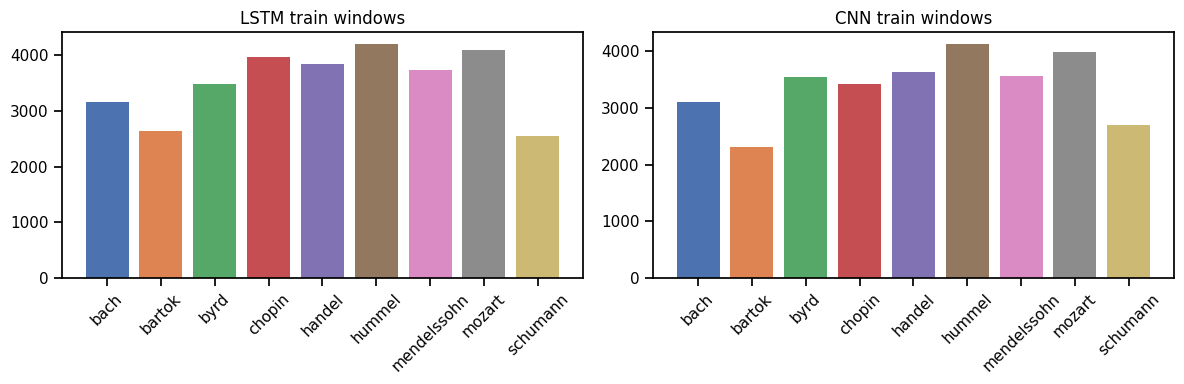

In [15]:
def show_distribution(y, title):
    counts = {IDX2LABEL[i]: int((y == i).sum()) for i in range(len(TARGET_COMPOSERS))}
    print(f"{title}: {counts}")
    return counts

print("Window counts per class")
_ = show_distribution(yseq_train, "LSTM train")
_ = show_distribution(ycnn_train, "CNN  train")

# Class weights (shared logic; computed separately per representation)
def class_weights(y):
    classes = np.arange(len(TARGET_COMPOSERS))
    w = compute_class_weight("balanced", classes=classes, y=y)
    return {int(c): float(wi) for c, wi in zip(classes, w)}

cw_seq = class_weights(yseq_train)
cw_cnn = class_weights(ycnn_train)
print("\nLSTM class weights:", {IDX2LABEL[k]: round(v, 3) for k, v in cw_seq.items()})
print("CNN  class weights:", {IDX2LABEL[k]: round(v, 3) for k, v in cw_cnn.items()})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (y, t) in zip(ax, [(yseq_train, "LSTM train windows"),
                          (ycnn_train, "CNN train windows")]):
    vals = [ (y == i).sum() for i in range(len(TARGET_COMPOSERS)) ]
    a.bar(TARGET_COMPOSERS, vals, color=sns.color_palette("deep", len(TARGET_COMPOSERS)))
    a.set_title(t); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7. Model 1 - LSTM

The LSTM classifies a window of ordered pitch tokens. An `Embedding` layer maps each of the 129 possible tokens (128 pitches + 1 padding index) to a dense vector; two stacked LSTM layers model temporal dependencies; dropout regularizes; and a softmax `Dense` layer outputs a probability over the composer classes.

**Key hyperparameters:** embedding dim 64, LSTM units 128 then 64, dropout 0.3, Adam optimizer, sparse categorical cross-entropy (labels are integers). These are explained in the report.

In [16]:
def build_lstm(units1=128, units2=64, emb_dim=64, dropout=0.3, lr=1e-3):
    set_seeds()
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN,)),
        layers.Embedding(input_dim=PITCH_VOCAB + 1, output_dim=emb_dim,
                         mask_zero=False),
        layers.LSTM(units1, return_sequences=True, dropout=dropout),
        layers.LSTM(units2, dropout=dropout),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(TARGET_COMPOSERS), activation="softmax"),
    ], name="LSTM_composer_classifier")
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

build_lstm().summary()

2026-07-19 00:28:08.744196: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-19 00:28:08.744376: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-19 00:28:08.744443: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-19 00:28:10.244982: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-19 00:28:10.245099: I external/local_xla/xla/stream_executor

Model: "LSTM_composer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,225 (629.79 KB)

 Trainable params: 161,225 (629.79 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model 2 - CNN

The CNN classifies a piano-roll window (128 pitches x `PR_TIME` frames x 1 channel). Three convolutional blocks (Conv -> BatchNorm -> MaxPool) grow the receptive field; global average pooling collapses the feature map; and a softmax `Dense` layer outputs the composer probabilities. Batch normalization and dropout provide regularization.

**Key hyperparameters:** filters 32 -> 64 -> 128, 3x3 kernels, dropout 0.3, Adam optimizer, sparse categorical cross-entropy.

In [17]:
def build_cnn(f1=32, f2=64, f3=128, dropout=0.3, lr=1e-3):
    set_seeds()
    model = models.Sequential([
        layers.Input(shape=(PR_PITCH, PR_TIME, 1)),
        layers.Conv2D(f1, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(f2, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(f3, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(len(TARGET_COMPOSERS), activation="softmax"),
    ], name="CNN_composer_classifier")
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

build_cnn().summary()

Model: "CNN_composer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,241 (434.54 KB)

 Trainable params: 110,793 (432.79 KB)

 Non-trainable params: 448 (1.75 KB)

## 9. Training with callbacks

Both models use the same training routine: **early stopping** on validation loss (restores the best weights) and **model checkpointing** to save the best model. Class weights address imbalance. Training and validation loss/accuracy are recorded for later plotting.

In [18]:
def train_model(build_fn, Xtr, ytr, Xval, yval, class_weight, tag, **kw):
    set_seeds()
    model = build_fn(**kw)
    ckpt_path = f"best_{tag}.keras"
    cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss",
                                  save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-5),
    ]
    history = model.fit(
        Xtr, ytr, validation_data=(Xval, yval),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weight, callbacks=cbs, verbose=2)
    return model, history

print("Training utility ready.")

Training utility ready.


## 10. Hyperparameter optimization

A small, honest grid search is run for each model over a few settings (learning rate and dropout). The configuration with the best **validation accuracy** is kept and later evaluated on the untouched test set. The grid is intentionally small so it finishes in a reasonable time; widen it if you have more compute.

> The printed table is produced at run time - copy its real values into the report's optimization table. No numbers are pre-filled.

In [19]:
LSTM_GRID = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 5e-4, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
]
CNN_GRID = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 5e-4, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
]

def grid_search(build_fn, grid, Xtr, ytr, Xval, yval, cw, tag):
    rows, best = [], None
    for i, params in enumerate(grid):
        model, hist = train_model(build_fn, Xtr, ytr, Xval, yval, cw,
                                  tag=f"{tag}_cfg{i}", **params)
        val_acc = max(hist.history["val_accuracy"])
        rows.append({**params, "best_val_acc": round(val_acc, 4)})
        if best is None or val_acc > best["val_acc"]:
            best = {"val_acc": val_acc, "params": params,
                    "model": model, "history": hist}
    table = pd.DataFrame(rows)
    print(f"\n{tag} grid-search results:\n", table)
    print(f"Best {tag} config: {best['params']} "
          f"(val_acc={best['val_acc']:.4f})")
    return best, table

In [20]:
# ---- Run LSTM search ----
best_lstm, lstm_grid_table = grid_search(
    build_lstm, LSTM_GRID, Xseq_train, yseq_train,
    Xseq_val, yseq_val, cw_seq, tag="lstm")
lstm_model, lstm_history = best_lstm["model"], best_lstm["history"]

Epoch 1/60


2026-07-19 00:28:20.176907: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


495/495 - 19s - 39ms/step - accuracy: 0.2056 - loss: 2.0760 - val_accuracy: 0.2153 - val_loss: 2.0692 - learning_rate: 0.0010
Epoch 2/60
495/495 - 13s - 26ms/step - accuracy: 0.2103 - loss: 2.0601 - val_accuracy: 0.1932 - val_loss: 2.0653 - learning_rate: 0.0010
Epoch 3/60
495/495 - 13s - 26ms/step - accuracy: 0.2344 - loss: 2.0001 - val_accuracy: 0.2593 - val_loss: 2.0178 - learning_rate: 0.0010
Epoch 4/60
495/495 - 13s - 26ms/step - accuracy: 0.2471 - loss: 1.9668 - val_accuracy: 0.1661 - val_loss: 2.1892 - learning_rate: 0.0010
Epoch 5/60
495/495 - 13s - 27ms/step - accuracy: 0.2728 - loss: 1.9206 - val_accuracy: 0.2983 - val_loss: 1.9463 - learning_rate: 0.0010
Epoch 6/60
495/495 - 13s - 26ms/step - accuracy: 0.2974 - loss: 1.8680 - val_accuracy: 0.2915 - val_loss: 1.9949 - learning_rate: 0.0010
Epoch 7/60
495/495 - 13s - 26ms/step - accuracy: 0.3000 - loss: 1.8629 - val_accuracy: 0.2763 - val_loss: 1.9572 - learning_rate: 0.0010
Epoch 8/60
495/495 - 13s - 26ms/step - accuracy: 0.3

In [ ]:
# ---- Run CNN search ----
best_cnn, cnn_grid_table = grid_search(
    build_cnn, CNN_GRID, Xcnn_train, ycnn_train,
    Xcnn_val, ycnn_val, cw_cnn, tag="cnn")
cnn_model, cnn_history = best_cnn["model"], best_cnn["history"]

2026-07-19 00:42:37.427529: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.
2026-07-19 00:42:48.479084: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.


Epoch 1/60


I0000 00:00:1784446976.729907   15858 service.cc:145] XLA service 0x72661000d910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784446976.730655   15858 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-07-19 00:42:57.555390: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784446989.422638   15858 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_4', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1784446989.426299   15858 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1784447008.106454   15858 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_6', 4 byt

475/475 - 40s - 84ms/step - accuracy: 0.6012 - loss: 1.0506 - val_accuracy: 0.0633 - val_loss: 21.5633 - learning_rate: 0.0010
Epoch 2/60
475/475 - 14s - 30ms/step - accuracy: 0.7833 - loss: 0.5839 - val_accuracy: 0.2408 - val_loss: 4.5566 - learning_rate: 0.0010
Epoch 3/60
475/475 - 14s - 30ms/step - accuracy: 0.8851 - loss: 0.3242 - val_accuracy: 0.2460 - val_loss: 9.4736 - learning_rate: 0.0010
Epoch 4/60
475/475 - 14s - 30ms/step - accuracy: 0.9475 - loss: 0.1636 - val_accuracy: 0.5589 - val_loss: 1.7763 - learning_rate: 0.0010
Epoch 5/60
475/475 - 14s - 30ms/step - accuracy: 0.9743 - loss: 0.0885 - val_accuracy: 0.2355 - val_loss: 10.5923 - learning_rate: 0.0010
Epoch 6/60
475/475 - 14s - 30ms/step - accuracy: 0.9821 - loss: 0.0612 - val_accuracy: 0.5659 - val_loss: 2.1365 - learning_rate: 0.0010
Epoch 7/60
475/475 - 14s - 30ms/step - accuracy: 0.9868 - loss: 0.0454 - val_accuracy: 0.6028 - val_loss: 1.7760 - learning_rate: 0.0010
Epoch 8/60
475/475 - 14s - 30ms/step - accuracy: 0

2026-07-19 00:46:50.645405: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.
2026-07-19 00:47:12.037258: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1990656000 exceeds 10% of free system memory.


Epoch 1/60
475/475 - 42s - 88ms/step - accuracy: 0.5709 - loss: 1.1374 - val_accuracy: 0.0633 - val_loss: 11.8769 - learning_rate: 5.0000e-04
Epoch 2/60
475/475 - 14s - 29ms/step - accuracy: 0.7335 - loss: 0.7111 - val_accuracy: 0.0931 - val_loss: 5.8334 - learning_rate: 5.0000e-04
Epoch 3/60
475/475 - 14s - 29ms/step - accuracy: 0.8249 - loss: 0.4825 - val_accuracy: 0.0650 - val_loss: 14.9170 - learning_rate: 5.0000e-04
Epoch 4/60
475/475 - 14s - 30ms/step - accuracy: 0.8944 - loss: 0.3102 - val_accuracy: 0.1213 - val_loss: 4.9936 - learning_rate: 5.0000e-04
Epoch 5/60
475/475 - 14s - 30ms/step - accuracy: 0.9429 - loss: 0.1881 - val_accuracy: 0.5589 - val_loss: 1.5078 - learning_rate: 5.0000e-04
Epoch 6/60
475/475 - 14s - 30ms/step - accuracy: 0.9674 - loss: 0.1169 - val_accuracy: 0.5448 - val_loss: 1.6328 - learning_rate: 5.0000e-04
Epoch 7/60
475/475 - 14s - 30ms/step - accuracy: 0.9805 - loss: 0.0769 - val_accuracy: 0.5290 - val_loss: 2.1142 - learning_rate: 5.0000e-04
Epoch 8/60


## 11. Training and validation curves

The curves below show loss and accuracy for training vs. validation across epochs for each model. A growing gap between the two curves indicates overfitting; flat, low curves indicate underfitting. Interpret these in the report using the figures produced here.

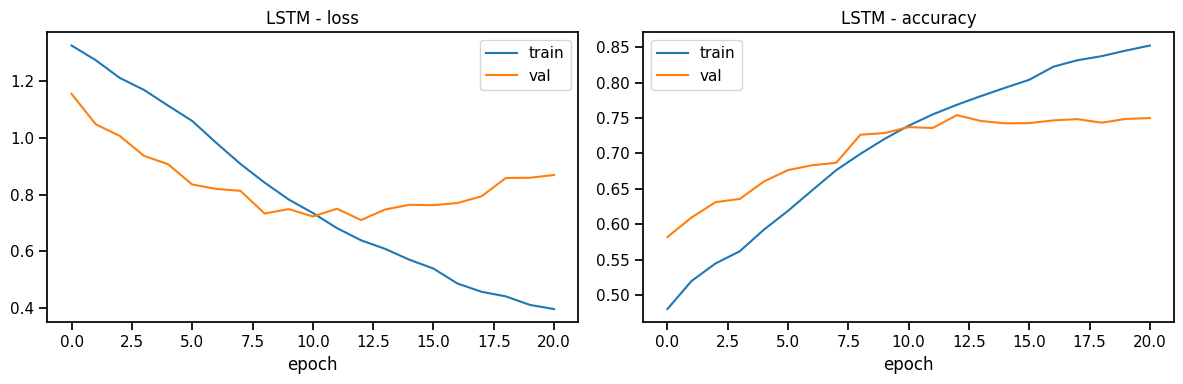

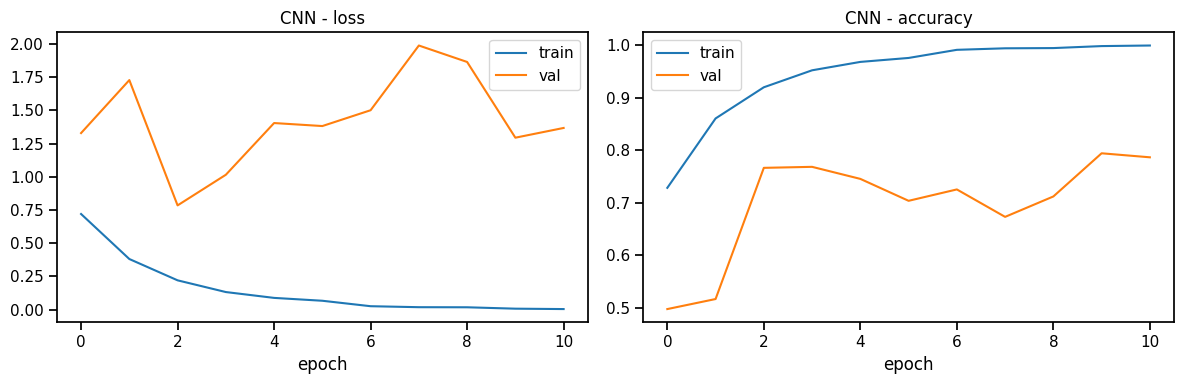

In [ ]:
def plot_history(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{title} - loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(lstm_history, "LSTM")
plot_history(cnn_history, "CNN")

## 12. Evaluation

Each model is evaluated on the held-out **test** set. The evaluation reports overall accuracy, a full classification report (per-class precision, recall, F1), and a confusion matrix. Macro and weighted averages are both reported: **macro** treats every composer equally (fair under imbalance), while **weighted** reflects the test-set class frequencies.

===== LSTM =====
Test accuracy      : 0.7129
Macro    P/R/F1    : 0.6487 / 0.6185 / 0.6303
Weighted P/R/F1    : 0.6960 / 0.7129 / 0.7007

Per-class classification report:
              precision    recall  f1-score   support

        Bach       0.80      0.92      0.86      1688
   Beethoven       0.55      0.45      0.50       609
      Chopin       0.67      0.62      0.64       335
      Mozart       0.57      0.48      0.52       694

    accuracy                           0.71      3326
   macro avg       0.65      0.62      0.63      3326
weighted avg       0.70      0.71      0.70      3326



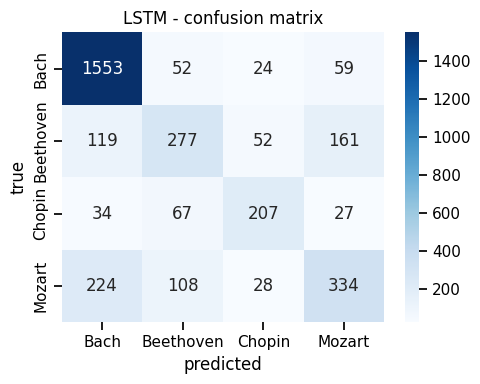

===== CNN =====
Test accuracy      : 0.7479
Macro    P/R/F1    : 0.6984 / 0.6750 / 0.6751
Weighted P/R/F1    : 0.7572 / 0.7479 / 0.7426

Per-class classification report:
              precision    recall  f1-score   support

        Bach       0.89      0.93      0.91      1476
   Beethoven       0.51      0.70      0.59       587
      Chopin       0.69      0.63      0.66       273
      Mozart       0.70      0.44      0.54       675

    accuracy                           0.75      3011
   macro avg       0.70      0.68      0.68      3011
weighted avg       0.76      0.75      0.74      3011



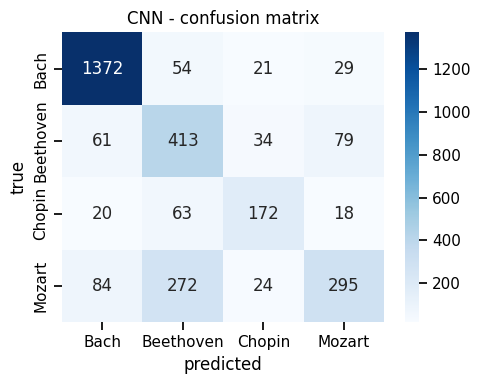

In [ ]:
def evaluate(model, X, y, title):
    proba = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    y_pred = proba.argmax(axis=1)
    acc = accuracy_score(y, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y, y_pred, average="weighted", zero_division=0)
    print(f"===== {title} =====")
    print(f"Test accuracy      : {acc:.4f}")
    print(f"Macro    P/R/F1    : {p_macro:.4f} / {r_macro:.4f} / {f_macro:.4f}")
    print(f"Weighted P/R/F1    : {p_w:.4f} / {r_w:.4f} / {f_w:.4f}\n")
    print("Per-class classification report:")
    print(classification_report(y, y_pred, target_names=TARGET_COMPOSERS,
                                zero_division=0))
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_COMPOSERS, yticklabels=TARGET_COMPOSERS)
    plt.title(f"{title} - confusion matrix")
    plt.xlabel("predicted"); plt.ylabel("true"); plt.tight_layout(); plt.show()
    return {"model": title, "accuracy": acc,
            "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f_macro,
            "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f_w}

lstm_metrics = evaluate(lstm_model, Xseq_test, yseq_test, "LSTM")
cnn_metrics  = evaluate(cnn_model,  Xcnn_test,  ycnn_test,  "CNN")

## 13. Model comparison

The final comparison table is assembled directly from the metric dictionaries computed above, so it always reflects the real run. Use it as the source for the report's results table.

Model comparison (test set):

       accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  \
model                                                                          
LSTM     0.7129           0.6487        0.6185    0.6303              0.6960   
CNN      0.7479           0.6984        0.6750    0.6751              0.7572   

       recall_weighted  f1_weighted  
model                                
LSTM            0.7129       0.7007  
CNN             0.7479       0.7426  


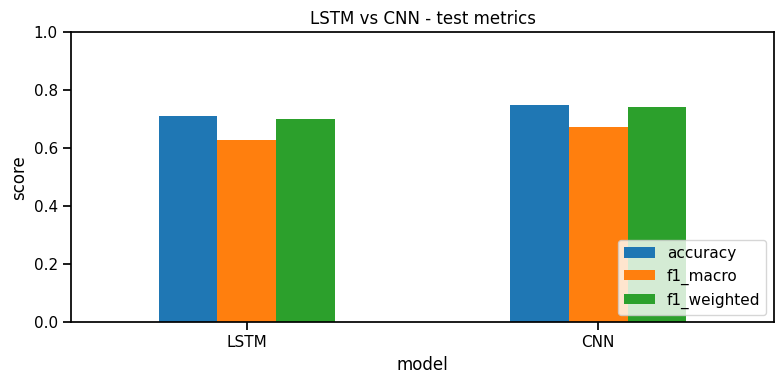


Saved model_comparison.csv


In [ ]:
comparison = pd.DataFrame([lstm_metrics, cnn_metrics]).set_index("model").round(4)
print("Model comparison (test set):\n")
print(comparison)

comparison[["accuracy", "f1_macro", "f1_weighted"]].plot(
    kind="bar", figsize=(8, 4))
plt.title("LSTM vs CNN - test metrics"); plt.ylabel("score")
plt.ylim(0, 1); plt.xticks(rotation=0); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# Save the comparison so it can be pasted into the report.
comparison.to_csv("model_comparison.csv")
print("\nSaved model_comparison.csv")

## 14. Conclusions and future improvements

Summarize your findings **from the printed results above** (do not invent numbers). Points to address, using the figures and tables this notebook generated:

- **Which model performed better** overall (compare the test accuracy and macro-F1 in the comparison table).
- **Which composers were easiest to classify** and **which were most often confused** (read this from the two confusion matrices).
- **Overfitting vs. underfitting** signals (read this from the training/validation curves in Section 11).
- **Effect of class imbalance** (compare macro vs. weighted F1, and relate to the class-distribution charts).

**Possible future improvements**

- Richer LSTM tokens that combine pitch with duration and velocity, or an event-based encoding (note-on/note-off/time-shift).
- Multi-channel piano rolls (separate instruments) or log-scaled time resolution for the CNN.
- Stronger regularization or a hybrid CRNN (convolutions feeding an LSTM).
- More composers, cross-dataset validation, and k-fold cross-validation for tighter confidence intervals.
- Handling polyphony and voice separation more explicitly.

> **Reminder:** replace the bracketed placeholders in the report with the actual numbers this notebook prints. Do not state that a model is "highly accurate" unless the printed metrics support it.


## 15. References (APA 7)

Abadi, M., Agarwal, A., Barham, P., Brevdo, E., Chen, Z., Citro, C., ... Zheng, X. (2015). *TensorFlow: Large-scale machine learning on heterogeneous systems*. https://www.tensorflow.org/

Chollet, F. (2015). *Keras* [Computer software]. https://keras.io/

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357-362. https://doi.org/10.1038/s41586-020-2649-2

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278-2324. https://doi.org/10.1109/5.726791

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56-61). https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Raffel, C., & Ellis, D. P. W. (2014). Intuitive analysis, creation and manipulation of MIDI data with pretty_midi. In *15th International Society for Music Information Retrieval Conference, Late-Breaking and Demo Session*.

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
